# Daily Rainfall Data from 2021 to 2023 of Tiruppur Region Analysis

### **Setup and Preprocessing**

In [ ]:
# Install required packages
!pip install tensorflow scikit-learn xgboost joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive (optional - if you want to save to Drive)
from google.colab import drive
drive.mount('/content/drive')

# For Colab, we'll save everything in the Colab environment
# If you want to save to Drive, change the base path to '/content/drive/MyDrive/...'

# Create directories in Colab environment
import os

def create_colab_directories(base_path='.'):
    """Create directories for organized saving in Colab"""
    directories = [
        f'{base_path}/models/ml_models',
        f'{base_path}/models/dl_models',
        f'{base_path}/models/ensemble',
        f'{base_path}/data/processed',
        f'{base_path}/models/scalers',
        f'{base_path}/models/feature_info'
    ]

    for directory in directories:
        os.makedirs(directory, exist_ok=True)
    print("Created all necessary directories in Colab environment")

create_colab_directories()

Mounted at /content/drive
Created all necessary directories in Colab environment


### **Data Preprocessing**

In [ ]:
# Load your data - ADJUST THIS PATH FOR YOUR COLAB UPLOAD
from google.colab import files
import io

# Method 1: Upload file directly
uploaded = files.upload()
filename = list(uploaded.keys())[0]
# Attempt to read the CSV with a different encoding
try:
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-8')
    print("Successfully read with utf-8 encoding")
except UnicodeDecodeError:
    print("UTF-8 decoding failed, trying latin-1")
    df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin-1')
    print("Successfully read with latin-1 encoding")

# Method 2: If file is already in Colab environment
# df = pd.read_csv('Daily_RFD_2021_to_2023.csv')

def preprocess_rainfall_data(df):
    # Convert coordinates to decimal degrees
    def dms_to_decimal(dms_str):
        try:
            # Handle different format variations
            if '°' in dms_str:
                parts = dms_str.replace('"', '').replace('°', ' ').replace("'", ' ').split()
            else:
                parts = dms_str.split()

            degrees = float(parts[0])
            minutes = float(parts[1]) if len(parts) > 1 else 0
            seconds = float(parts[2]) if len(parts) > 2 else 0
            return degrees + minutes/60 + seconds/3600
        except Exception as e:
            print(f"Error converting {dms_str}: {e}")
            return np.nan

    # Create datetime column
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    df = df.sort_values('date')

    # Convert coordinates
    df['Latitude_decimal'] = df['Latitude'].apply(dms_to_decimal)
    df['Longitude_decimal'] = df['Longitude'].apply(dms_to_decimal)

    # Handle missing values
    df['RF in mm'] = df['RF in mm'].fillna(0)

    # Feature engineering
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)

    # Lag features
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'rf_lag_{lag}'] = df['RF in mm'].shift(lag)

    # Rolling statistics
    df['rf_rolling_mean_7'] = df['RF in mm'].rolling(window=7, min_periods=1).mean()
    df['rf_rolling_std_7'] = df['RF in mm'].rolling(window=7, min_periods=1).std()
    df['rf_rolling_max_7'] = df['RF in mm'].rolling(window=7, min_periods=1).max()

    # Seasonal features
    df['sin_day_of_year'] = np.sin(2 * np.pi * df['day_of_year']/365.25)
    df['cos_day_of_year'] = np.cos(2 * np.pi * df['day_of_year']/365.25)

    # Binary rain indicator
    df['rained'] = (df['RF in mm'] > 0).astype(int)

    return df.dropna()

processed_df = preprocess_rainfall_data(df)
print(f"Processed data shape: {processed_df.shape}")

Saving Daily_RFD_2021_to_2023.csv to Daily_RFD_2021_to_2023.csv
UTF-8 decoding failed, trying latin-1
Successfully read with latin-1 encoding
Processed data shape: (30539, 29)


### **Feature Selection and Data Preparation**

In [ ]:
def prepare_features(df, target_col='RF in mm'):
    # Select features
    feature_columns = [
        'day_of_year', 'month', 'year', 'quarter', 'is_weekend',
        'rf_lag_1', 'rf_lag_2', 'rf_lag_3', 'rf_lag_7', 'rf_lag_14', 'rf_lag_30',
        'rf_rolling_mean_7', 'rf_rolling_std_7', 'rf_rolling_max_7',
        'sin_day_of_year', 'cos_day_of_year', 'rained'
    ]

    # Remove any remaining NaN columns
    feature_columns = [col for col in feature_columns if col in df.columns]
    X = df[feature_columns]
    y = df[target_col]

    # Feature selection
    selector = SelectKBest(score_func=mutual_info_regression, k=min(10, len(feature_columns)))
    X_selected = selector.fit_transform(X, y)

    selected_features = X.columns[selector.get_support()]
    print(f"Selected features: {list(selected_features)}")

    return X[selected_features], y, selected_features

X, y, selected_features = prepare_features(processed_df)

# Train-test split with time series consideration
def timeseries_train_test_split(X, y, test_size=0.2):
    split_index = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = timeseries_train_test_split(X, y)

# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Selected features: ['day_of_year', 'rf_lag_1', 'rf_lag_2', 'rf_lag_3', 'rf_lag_7', 'rf_rolling_mean_7', 'rf_rolling_std_7', 'rf_rolling_max_7', 'sin_day_of_year', 'rained']
Training data shape: (24431, 10)
Test data shape: (6108, 10)


### **Save Preprocessed Data**

In [ ]:
def save_preprocessed_data_colab(processed_df, X, y, selected_features, base_path='.'):
    """Save preprocessed data and feature information in Colab"""

    # Save the main processed DataFrame
    processed_df.to_csv(f'{base_path}/data/processed/preprocessed_rainfall_data.csv', index=False)
    print("✓ Saved preprocessed data")

    # Save feature and target data separately for easy reloading
    X.to_csv(f'{base_path}/data/processed/features_data.csv', index=False)
    y.to_csv(f'{base_path}/data/processed/target_data.csv', index=False)
    print("✓ Saved features and target data separately")

    # Save selected features information
    feature_info = {
        'selected_features': list(selected_features),
        'feature_count': len(selected_features),
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'data_shape': {
            'X_shape': X.shape,
            'y_shape': y.shape
        }
    }

    with open(f'{base_path}/models/feature_info/selected_features.json', 'w') as f:
        json.dump(feature_info, f, indent=4)
    print("✓ Saved feature information")

    return feature_info

feature_info = save_preprocessed_data_colab(processed_df, X, y, selected_features)

✓ Saved preprocessed data
✓ Saved features and target data separately
✓ Saved feature information


### **Save Scalers**

In [ ]:
def save_scalers_colab(scaler_X, scaler_y, feature_info, base_path='.'):
    """Save scalers and preprocessing objects in Colab"""

    # Save scalers
    joblib.dump(scaler_X, f'{base_path}/models/scalers/feature_scaler.pkl')
    joblib.dump(scaler_y, f'{base_path}/models/scalers/target_scaler.pkl')
    print("✓ Saved feature and target scalers")

    # Save preprocessing metadata
    preprocessing_metadata = {
        'feature_names': feature_info['selected_features'],
        'scaler_X_params': {
            'mean': scaler_X.mean_.tolist() if hasattr(scaler_X, 'mean_') else 'Not available',
            'scale': scaler_X.scale_.tolist() if hasattr(scaler_X, 'scale_') else 'Not available'
        },
        'scaler_y_params': {
            'mean': scaler_y.mean_.tolist() if hasattr(scaler_y, 'mean_') else 'Not available',
            'scale': scaler_y.scale_.tolist() if hasattr(scaler_y, 'scale_') else 'Not available'
        },
        'saved_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    with open(f'{base_path}/models/scalers/preprocessing_metadata.json', 'w') as f:
        json.dump(preprocessing_metadata, f, indent=4)
    print("✓ Saved preprocessing metadata")

    return preprocessing_metadata

preprocessing_metadata = save_scalers_colab(scaler_X, scaler_y, feature_info)

✓ Saved feature and target scalers
✓ Saved preprocessing metadata


### **Train and Save ML Models**

In [ ]:
# Train some baseline models first
def train_baseline_ml_models(X_train_scaled, y_train_scaled):
    """Train baseline ML models"""
    models = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    trained_models = {}
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train_scaled, y_train_scaled)
        trained_models[name] = model
        print(f"✓ {name} trained")

    return trained_models

# Train models
trained_ml_models = train_baseline_ml_models(X_train_scaled, y_train_scaled)

# Fine-tune XGBoost (simplified for Colab)
def fine_tune_xgboost(X_train_scaled, y_train_scaled):
    """Fine-tune XGBoost with simplified parameter grid for Colab"""
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 0.9]
    }

    xgb_model = xgb.XGBRegressor(random_state=42)

    # Use fewer CV splits for faster training in Colab
    grid_search = GridSearchCV(
        xgb_model, param_grid, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=1
    )

    grid_search.fit(X_train_scaled, y_train_scaled)
    print(f"Best parameters: {grid_search.best_params_}")

    return grid_search.best_estimator_

# Fine-tune Random Forest
def fine_tune_random_forest(X_train_scaled, y_train_scaled):
    """Fine-tune Random Forest with simplified parameter grid for Colab"""
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    rf_model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        rf_model, param_grid, cv=3, scoring='neg_mean_squared_error',
        n_jobs=-1, verbose=1
    )

    grid_search.fit(X_train_scaled, y_train_scaled)
    print(f"Best parameters: {grid_search.best_params_}")

    return grid_search.best_estimator_

print("Fine-tuning XGBoost...")
best_xgb = fine_tune_xgboost(X_train_scaled, y_train_scaled)

print("Fine-tuning Random Forest...")
best_rf = fine_tune_random_forest(X_train_scaled, y_train_scaled)

# Save ML models
def save_ml_models_colab(ml_models_dict, base_path='.'):
    """Save ML models in Colab environment"""

    ml_models_info = {}

    for model_name, model in ml_models_dict.items():
        safe_name = model_name.lower().replace(' ', '_')
        filename = f'{base_path}/models/ml_models/{safe_name}.pkl'
        joblib.dump(model, filename)

        ml_models_info[model_name] = {
            'filename': filename,
            'type': 'tuned' if 'best' in model_name else 'baseline',
            'saved_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        print(f"✓ Saved {model_name}")

    # Save ML models metadata
    with open(f'{base_path}/models/ml_models/ml_models_metadata.json', 'w') as f:
        json.dump(ml_models_info, f, indent=4)
    print("✓ Saved ML models metadata")

    return ml_models_info

# Prepare models for saving
models_to_save = {
    'random_forest_baseline': trained_ml_models['Random Forest'],
    'xgboost_baseline': trained_ml_models['XGBoost'],
    'random_forest_tuned': best_rf,
    'xgboost_tuned': best_xgb
}

ml_models_info = save_ml_models_colab(models_to_save)

Training Random Forest...
✓ Random Forest trained
Training XGBoost...
✓ XGBoost trained
Training Gradient Boosting...
✓ Gradient Boosting trained
Fine-tuning XGBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Fine-tuning Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
✓ Saved random_forest_baseline
✓ Saved xgboost_baseline
✓ Saved random_forest_tuned
✓ Saved xgboost_tuned
✓ Saved ML models metadata


### **Train and Save DL Models**

In [ ]:
# Prepare sequences for DL models
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Prepare sequences
time_steps = 30
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
# Scale y_test using the fitted scaler_y
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)


print(f"Sequence data shapes - X_train: {X_train_seq.shape}, y_train: {y_train_seq.shape}")
print(f"Sequence data shapes - X_test: {X_test_seq.shape}, y_test: {y_test_seq.shape}")


# Create LSTM model (simplified for Colab)
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        LSTM(32, return_sequences=True),
        Dropout(0.3),
        LSTM(16),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Create CNN-LSTM model (simplified for Colab)
def create_cnn_lstm_model(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(50, return_sequences=True),
        Dropout(0.3),
        LSTM(25),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Train LSTM model
print("Training LSTM model...")
lstm_model = create_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,  # Reduced for Colab
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# Train CNN-LSTM model
print("Training CNN-LSTM model...")
cnn_lstm_model = create_cnn_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,  # Reduced for Colab
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=5, factor=0.5)
    ],
    verbose=1
)

# Save DL models
def save_dl_models_colab(dl_models_dict, base_path='.'):
    """Save DL models in Colab environment"""

    dl_models_info = {}

    for model_name, model in dl_models_dict.items():
        safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
        model_path = f'{base_path}/models/dl_models/{safe_name}.keras' # Add .keras extension

        # Save model
        model.save(model_path)

        dl_models_info[model_name] = {
            'model_path': model_path,
            'input_shape': str(model.input_shape),
            'output_shape': str(model.output_shape),
            'trainable_params': model.count_params(),
            'saved_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        print(f"✓ Saved {model_name}")

    # Save DL models metadata
    with open(f'{base_path}/models/dl_models/dl_models_metadata.json', 'w') as f:
        json.dump(dl_models_info, f, indent=4)
    print("✓ Saved DL models metadata")

    return dl_models_info

# Save DL models
dl_models_to_save = {
    'lstm_model': lstm_model,
    'cnn_lstm_model': cnn_lstm_model
}

dl_models_info = save_dl_models_colab(dl_models_to_save)

Sequence data shapes - X_train: (24401, 30, 10), y_train: (24401,)
Sequence data shapes - X_test: (6078, 30, 10), y_test: (6078,)
Training LSTM model...
Epoch 1/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.9551 - mae: 0.3858 - val_loss: 0.3764 - val_mae: 0.2360 - learning_rate: 0.0010
Epoch 2/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.9148 - mae: 0.3623 - val_loss: 0.3708 - val_mae: 0.2372 - learning_rate: 0.0010
Epoch 3/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.8689 - mae: 0.3526 - val_loss: 0.3647 - val_mae: 0.2019 - learning_rate: 0.0010
Epoch 4/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.8567 - mae: 0.3496 - val_loss: 0.3582 - val_mae: 0.1969 - learning_rate: 0.0010
Epoch 5/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.8324 - mae: 0.3419 - val_loss: 0.3671 - val_mae: 0.2037 - learning_rate: 0.0010
Epoch 6/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.8398 - mae: 0.3415 - val_loss: 0.3651 - val_mae: 0.2255 - learning_r

### **Save Training History and Create Model Loader**

In [ ]:
def save_training_history_colab(histories, base_path='.'):
    """Save training history in Colab"""

    training_history = {}
    for model_name, history in histories.items():
        training_history[model_name] = {
            'loss': history.history['loss'],
            'val_loss': history.history['val_loss'],
            'mae': history.history['mae'],
            'val_mae': history.history['val_mae'],
            'epochs': len(history.history['loss']),
            'final_loss': history.history['loss'][-1],
            'final_val_loss': history.history['val_loss'][-1]
        }

    with open(f'{base_path}/models/dl_models/training_history.json', 'w') as f:
        json.dump(training_history, f, indent=4)
    print("✓ Saved training history")

# Save training history
histories_to_save = {
    'lstm': lstm_history,
    'cnn_lstm': cnn_lstm_history
}

save_training_history_colab(histories_to_save)

# Create Colab-compatible model loader
def create_colab_model_loader(base_path='.'):
    """Create a model loader script for Colab"""

    loader_code = f'''
import pandas as pd
import numpy as np
import joblib
import json
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings('ignore')

class RainfallPredictor:
    """A class to load and use trained rainfall prediction models in Colab"""

    def __init__(self, base_path="{base_path}"):
        self.base_path = base_path
        self.scalers_loaded = False
        self.features_loaded = False
        self.models_loaded = False

    def load_scalers(self):
        """Load feature and target scalers"""
        try:
            self.scaler_X = joblib.load(f'{{self.base_path}}/models/scalers/feature_scaler.pkl')
            self.scaler_y = joblib.load(f'{{self.base_path}}/models/scalers/target_scaler.pkl')
            self.scalers_loaded = True
            print("✓ Scalers loaded successfully")
            return True
        except Exception as e:
            print(f"✗ Error loading scalers: {{e}}")
            return False

    def load_feature_info(self):
        """Load feature information"""
        try:
            with open(f'{{self.base_path}}/models/feature_info/selected_features.json', 'r') as f:
                self.feature_info = json.load(f)
            self.selected_features = self.feature_info['selected_features']
            self.features_loaded = True
            print("✓ Feature information loaded successfully")
            return True
        except Exception as e:
            print(f"✗ Error loading feature info: {{e}}")
            return False

    def load_ml_model(self, model_name):
        """Load a specific ML model"""
        try:
            model_path = f'{{self.base_path}}/models/ml_models/{{model_name}}.pkl'
            model = joblib.load(model_path)
            print(f"✓ ML model '{{model_name}}' loaded successfully")
            return model
        except Exception as e:
            print(f"✗ Error loading ML model '{{model_name}}': {{e}}")
            return None

    def load_dl_model(self, model_name):
        """Load a specific DL model"""
        try:
            model_path = f'{{self.base_path}}/models/dl_models/{{model_name}}'
            model = load_model(model_path)
            print(f"✓ DL model '{{model_name}}' loaded successfully")
            return model
        except Exception as e:
            print(f"✗ Error loading DL model '{{model_name}}': {{e}}")
            return None

    def load_all_models(self):
        """Load all models and preprocessing objects"""
        self.load_scalers()
        self.load_feature_info()

        # Load ML models
        self.ml_models = {{}}
        ml_model_names = ['random_forest_tuned', 'xgboost_tuned']

        for model_name in ml_model_names:
            self.ml_models[model_name] = self.load_ml_model(model_name)

        # Load DL models
        self.dl_models = {{}}
        dl_model_names = ['lstm_model', 'cnn_lstm_model']

        for model_name in dl_model_names:
            self.dl_models[model_name] = self.load_dl_model(model_name)

        self.models_loaded = True
        print("✓ All models loaded successfully")

    def preprocess_new_data(self, new_data):
        """Preprocess new data for prediction"""
        if not self.features_loaded:
            self.load_feature_info()

        # Select only the required features
        required_features = self.selected_features
        available_features = [f for f in required_features if f in new_data.columns]

        if len(available_features) != len(required_features):
            print(f"Warning: Missing features. Expected {{len(required_features)}}, found {{len(available_features)}}")

        X_new = new_data[available_features]

        # Scale the features
        if self.scalers_loaded:
            X_new_scaled = self.scaler_X.transform(X_new)
        else:
            print("Warning: Scalers not loaded. Using unscaled data.")
            X_new_scaled = X_new.values

        return X_new_scaled

    def predict_rainfall_ml(self, new_data, model_name='xgboost_tuned'):
        """Make rainfall predictions using ML model"""
        if not self.models_loaded:
            self.load_all_models()

        # Preprocess data
        X_new_scaled = self.preprocess_new_data(new_data)

        # Make predictions
        if model_name in self.ml_models and self.ml_models[model_name] is not None:
            y_pred_scaled = self.ml_models[model_name].predict(X_new_scaled)
            y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            return y_pred
        else:
            print(f"ML model '{{model_name}}' not found")
            return None

    def predict_rainfall_dl(self, new_data, model_name='lstm_model', sequence_length=30):
        """Make rainfall predictions using DL model"""
        if not self.models_loaded:
            self.load_all_models()

        # Preprocess data
        X_new_scaled = self.preprocess_new_data(new_data)

        # Reshape for DL models (create sequences)
        if len(X_new_scaled) < sequence_length:
            print(f"Warning: Need at least {{sequence_length}} data points for DL prediction")
            return None

        # Create sequence
        X_seq = X_new_scaled[-sequence_length:].reshape(1, sequence_length, X_new_scaled.shape[1])

        # Make predictions
        if model_name in self.dl_models and self.dl_models[model_name] is not None:
            y_pred_scaled = self.dl_models[model_name].predict(X_seq).flatten()
            y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            return y_pred
        else:
            print(f"DL model '{{model_name}}' not found")
            return None

# Example usage:
# predictor = RainfallPredictor()
# predictor.load_all_models()
#
# For ML prediction:
# predictions_ml = predictor.predict_rainfall_ml(new_data, 'xgboost_tuned')
#
# For DL prediction:
# predictions_dl = predictor.predict_rainfall_dl(new_data, 'lstm_model')
'''

    with open(f'{base_path}/model_loader_colab.py', 'w') as f:
        f.write(loader_code)
    print("✓ Created model_loader_colab.py")

create_colab_model_loader()

✓ Saved training history
✓ Created model_loader_colab.py


In [ ]:
def verify_and_download_colab(base_path='.'):
    """Verify saved models and provide download options"""

    print("="*60)
    print("VERIFYING SAVED MODELS IN COLAB")
    print("="*60)

    files_to_verify = [
        f'{base_path}/data/processed/preprocessed_rainfall_data.csv',
        f'{base_path}/models/feature_info/selected_features.json',
        f'{base_path}/models/scalers/feature_scaler.pkl',
        f'{base_path}/models/scalers/target_scaler.pkl',
        f'{base_path}/models/ml_models/xgboost_tuned.pkl',
        f'{base_path}/models/ml_models/random_forest_tuned.pkl',
        f'{base_path}/models/dl_models/lstm_model.keras',
        f'{base_path}/models/dl_models/cnn_lstm_model.keras',
        f'{base_path}/model_loader_colab.py'
    ]

    all_files_exist = True
    for file_path in files_to_verify:
        if os.path.exists(file_path):
            print(f"✓ {file_path}")
        else:
            print(f"✗ {file_path} - MISSING")
            all_files_exist = False

    print("\\n" + "="*60)
    if all_files_exist:
        print("🎉 SUCCESS: All models and data saved successfully!")
        print("You can now use model_loader_colab.py to load models for predictions.")
    else:
        print("⚠️  WARNING: Some files are missing.")
    print("="*60)

    # Provide download options
    print("\\n📥 DOWNLOAD OPTIONS:")
    print("1. Download individual files/folders using Colab file browser")
    print("2. Download entire models folder:")
    print("   - Right-click on 'models' folder in Colab file browser")
    print("   - Select 'Download'")
    print("3. Or use this code to create a zip file:")

    zip_code = '''
# Create zip file of all models
import shutil
shutil.make_archive('rainfall_models', 'zip', 'models')
print("✓ Created rainfall_models.zip")

# Download the zip file
from google.colab import files
files.download('rainfall_models.zip')
'''

    print(zip_code)

verify_and_download_colab()

# Test the model loader
def test_colab_loader():
    """Test if the model loader works in Colab"""
    print("\\n🧪 TESTING MODEL LOADER...")

    try:
        # Import the loader we just created
        from model_loader_colab import RainfallPredictor

        # Initialize predictor
        predictor = RainfallPredictor()

        # Test loading
        predictor.load_scalers()
        predictor.load_feature_info()

        # Test loading one ML model
        test_model = predictor.load_ml_model('xgboost_tuned')
        if test_model:
            print("✅ Model loader working correctly!")
        else:
            print("❌ Model loader has issues")

    except Exception as e:
        print(f"❌ Error testing model loader: {e}")

test_colab_loader()

# Create a zip file for easy download
print("\\n📦 CREATING DOWNLOADABLE ZIP FILE...")
import shutil
shutil.make_archive('Rainfall_ML_DL_Models', 'zip', 'models')
print("✓ Created Rainfall_ML_DL_Models.zip")
shutil.make_archive('Preprocessed_Data', 'zip', 'data')
print("✓ Created Preprocessed_Data.zip")

# Download the zip file
print("\\n⬇️  DOWNLOADING MODELS...")
from google.colab import files
files.download('Rainfall_ML_DL_Models.zip')
files.download('Preprocessed_Data.zip')
files.download('model_loader_colab.py')
print("✓ Download initiated!")

print("\\n🎯 NEXT STEPS:")
print("1. Use 'model_loader_colab.py' to load models in future Colab sessions")
print("2. Upload 'rainfall_models.zip' to your Drive for permanent storage")
print("3. Extract the zip file and update base_path in RainfallPredictor if needed")

VERIFYING SAVED MODELS IN COLAB
✓ ./data/processed/preprocessed_rainfall_data.csv
✓ ./models/feature_info/selected_features.json
✓ ./models/scalers/feature_scaler.pkl
✓ ./models/scalers/target_scaler.pkl
✓ ./models/ml_models/xgboost_tuned.pkl
✓ ./models/ml_models/random_forest_tuned.pkl
✓ ./models/dl_models/lstm_model.keras
✓ ./models/dl_models/cnn_lstm_model.keras
✓ ./model_loader_colab.py
\n============================================================
🎉 SUCCESS: All models and data saved successfully!
You can now use model_loader_colab.py to load models for predictions.
\n📥 DOWNLOAD OPTIONS:
1. Download individual files/folders using Colab file browser
2. Download entire models folder:
   - Right-click on 'models' folder in Colab file browser
   - Select 'Download'
3. Or use this code to create a zip file:

# Create zip file of all models
import shutil
shutil.make_archive('rainfall_models', 'zip', 'models')
print("✓ Created rainfall_models.zip")
    
# Download the zip file
from googl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download initiated!
\n🎯 NEXT STEPS:
1. Use 'model_loader_colab.py' to load models in future Colab sessions
2. Upload 'rainfall_models.zip' to your Drive for permanent storage
3. Extract the zip file and update base_path in RainfallPredictor if needed


### **Performance Evaluation Functions**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

def evaluate_all_models(X_train_scaled, X_test_scaled, y_train, y_test,
                       X_train_seq, X_test_seq, y_train_seq, y_test_seq,
                       ml_models, dl_models, scaler_y):
    """Evaluate all models and return performance metrics"""

    performance_results = {}

    # Evaluate ML models
    print("Evaluating ML Models...")
    for model_name, model in ml_models.items():
        if 'tuned' in model_name:  # Only evaluate tuned models for clarity
            # Make predictions
            y_pred_scaled = model.predict(X_test_scaled)
            y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            performance_results[model_name] = {
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2,
                'Predictions': y_pred,
                'Type': 'ML'
            }
            print(f"✓ {model_name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

    # Evaluate DL models
    print("\nEvaluating DL Models...")
    for model_name, model in dl_models.items():
        # Make predictions
        y_pred_scaled = model.predict(X_test_seq)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
        y_true_dl = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

        # Calculate metrics
        mae = mean_absolute_error(y_true_dl, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true_dl, y_pred))
        r2 = r2_score(y_true_dl, y_pred)

        performance_results[model_name] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Predictions': y_pred,
            'True_Values': y_true_dl,
            'Type': 'DL'
        }
        print(f"✓ {model_name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

    return performance_results

# Get all trained models for evaluation
ml_models_for_eval = {
    'random_forest_tuned': best_rf,
    'xgboost_tuned': best_xgb
}

dl_models_for_eval = {
    'lstm_model': lstm_model,
    'cnn_lstm_model': cnn_lstm_model
}

# Evaluate all models
performance_results = evaluate_all_models(
    X_train_scaled, X_test_scaled, y_train, y_test,
    X_train_seq, X_test_seq, y_train_seq, y_test_seq,
    ml_models_for_eval, dl_models_for_eval, scaler_y
)

Evaluating ML Models...
✓ random_forest_tuned: MAE=0.9724, RMSE=4.7180, R²=0.6380
✓ xgboost_tuned: MAE=1.1409, RMSE=4.8156, R²=0.6228

Evaluating DL Models...
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
✓ lstm_model: MAE=2.3863, RMSE=7.2226, R²=0.1441
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✓ cnn_lstm_model: MAE=2.5488, RMSE=7.1484, R²=0.1616


### **Comprehensive Performance Visualization**

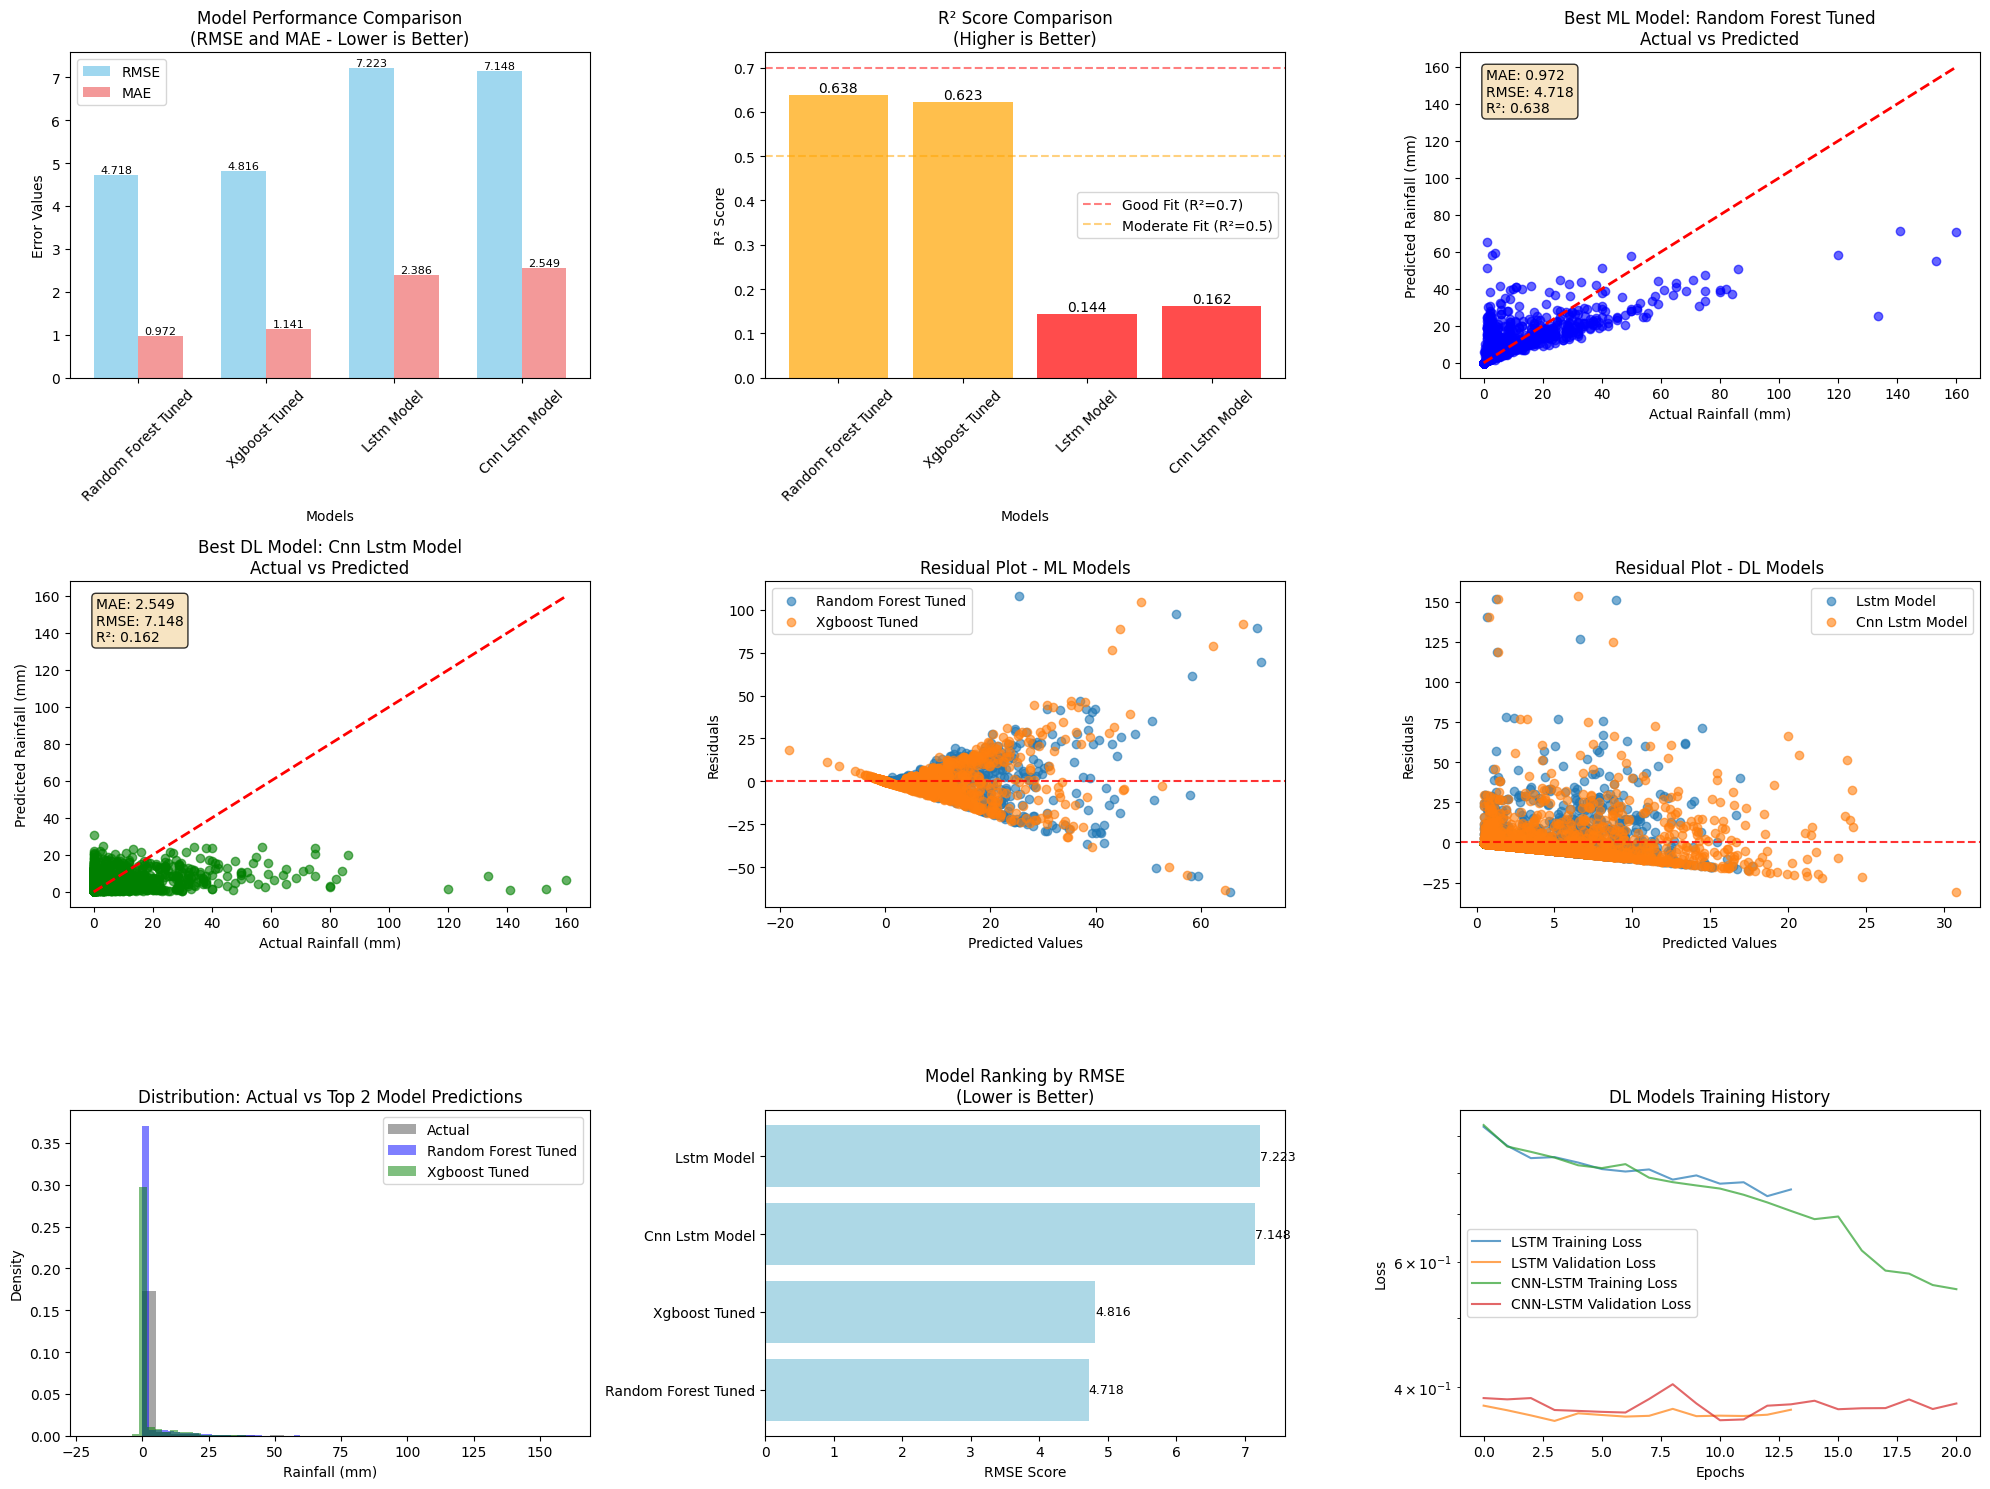

In [ ]:
def plot_comprehensive_performance(performance_results, y_test, y_test_seq, scaler_y):
    """Create comprehensive performance plots"""

    # Create subplots
    fig = plt.figure(figsize=(20, 15))

    # 1. Model Comparison Bar Plot
    ax1 = plt.subplot(3, 3, 1)
    models = list(performance_results.keys())
    rmse_values = [performance_results[model]['RMSE'] for model in models]
    mae_values = [performance_results[model]['MAE'] for model in models]

    x = np.arange(len(models))
    width = 0.35

    bars1 = ax1.bar(x - width/2, rmse_values, width, label='RMSE', alpha=0.8, color='skyblue')
    bars2 = ax1.bar(x + width/2, mae_values, width, label='MAE', alpha=0.8, color='lightcoral')

    ax1.set_xlabel('Models')
    ax1.set_ylabel('Error Values')
    ax1.set_title('Model Performance Comparison\n(RMSE and MAE - Lower is Better)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([m.replace('_', ' ').title() for m in models], rotation=45)
    ax1.legend()

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # 2. R² Score Comparison
    ax2 = plt.subplot(3, 3, 2)
    r2_values = [performance_results[model]['R2'] for model in models]
    colors = ['green' if val > 0.7 else 'orange' if val > 0.5 else 'red' for val in r2_values]

    bars = ax2.bar(models, r2_values, color=colors, alpha=0.7)
    ax2.set_xlabel('Models')
    ax2.set_ylabel('R² Score')
    ax2.set_title('R² Score Comparison\n(Higher is Better)')
    ax2.set_xticklabels([m.replace('_', ' ').title() for m in models], rotation=45)
    ax2.axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Good Fit (R²=0.7)')
    ax2.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, label='Moderate Fit (R²=0.5)')
    ax2.legend()

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # 3. Actual vs Predicted for Best ML Model
    ax3 = plt.subplot(3, 3, 3)
    best_ml_model = min([m for m in models if performance_results[m]['Type'] == 'ML'],
                       key=lambda x: performance_results[x]['RMSE'])

    y_pred_ml = performance_results[best_ml_model]['Predictions']
    ax3.scatter(y_test, y_pred_ml, alpha=0.6, color='blue')
    ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax3.set_xlabel('Actual Rainfall (mm)')
    ax3.set_ylabel('Predicted Rainfall (mm)')
    ax3.set_title(f'Best ML Model: {best_ml_model.replace("_", " ").title()}\nActual vs Predicted')

    # Add performance metrics to plot
    metrics_text = f'MAE: {performance_results[best_ml_model]["MAE"]:.3f}\nRMSE: {performance_results[best_ml_model]["RMSE"]:.3f}\nR²: {performance_results[best_ml_model]["R2"]:.3f}'
    ax3.text(0.05, 0.95, metrics_text, transform=ax3.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # 4. Actual vs Predicted for Best DL Model
    ax4 = plt.subplot(3, 3, 4)
    best_dl_model = min([m for m in models if performance_results[m]['Type'] == 'DL'],
                       key=lambda x: performance_results[x]['RMSE'])

    y_pred_dl = performance_results[best_dl_model]['Predictions']
    y_true_dl = performance_results[best_dl_model]['True_Values']
    ax4.scatter(y_true_dl, y_pred_dl, alpha=0.6, color='green')
    ax4.plot([y_true_dl.min(), y_true_dl.max()], [y_true_dl.min(), y_true_dl.max()], 'r--', lw=2)
    ax4.set_xlabel('Actual Rainfall (mm)')
    ax4.set_ylabel('Predicted Rainfall (mm)')
    ax4.set_title(f'Best DL Model: {best_dl_model.replace("_", " ").title()}\nActual vs Predicted')

    # Add performance metrics to plot
    metrics_text = f'MAE: {performance_results[best_dl_model]["MAE"]:.3f}\nRMSE: {performance_results[best_dl_model]["RMSE"]:.3f}\nR²: {performance_results[best_dl_model]["R2"]:.3f}'
    ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # 5. Residual Plots for ML Models
    ax5 = plt.subplot(3, 3, 5)
    for model_name in [m for m in models if performance_results[m]['Type'] == 'ML']:
        y_pred = performance_results[model_name]['Predictions']
        residuals = y_test - y_pred
        ax5.scatter(y_pred, residuals, alpha=0.6, label=model_name.replace('_', ' ').title())

    ax5.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    ax5.set_xlabel('Predicted Values')
    ax5.set_ylabel('Residuals')
    ax5.set_title('Residual Plot - ML Models')
    ax5.legend()

    # 6. Residual Plots for DL Models
    ax6 = plt.subplot(3, 3, 6)
    for model_name in [m for m in models if performance_results[m]['Type'] == 'DL']:
        y_pred = performance_results[model_name]['Predictions']
        y_true = performance_results[model_name]['True_Values']
        residuals = y_true - y_pred
        ax6.scatter(y_pred, residuals, alpha=0.6, label=model_name.replace('_', ' ').title())

    ax6.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    ax6.set_xlabel('Predicted Values')
    ax6.set_ylabel('Residuals')
    ax6.set_title('Residual Plot - DL Models')
    ax6.legend()

    # 7. Prediction Distribution Comparison
    ax7 = plt.subplot(3, 3, 7)
    # Plot actual distribution
    ax7.hist(y_test, bins=30, alpha=0.7, label='Actual', color='gray', density=True)

    # Plot predicted distributions for top 2 models
    top_models = sorted(models, key=lambda x: performance_results[x]['RMSE'])[:2]
    colors = ['blue', 'green']
    for i, model_name in enumerate(top_models):
        y_pred = performance_results[model_name]['Predictions']
        ax7.hist(y_pred, bins=30, alpha=0.5,
                label=f'{model_name.replace("_", " ").title()}',
                color=colors[i], density=True)

    ax7.set_xlabel('Rainfall (mm)')
    ax7.set_ylabel('Density')
    ax7.set_title('Distribution: Actual vs Top 2 Model Predictions')
    ax7.legend()

    # 8. Model Ranking
    ax8 = plt.subplot(3, 3, 8)
    ranked_models = sorted(models, key=lambda x: performance_results[x]['RMSE'])
    ranks = range(1, len(ranked_models) + 1)
    rmse_scores = [performance_results[model]['RMSE'] for model in ranked_models]

    bars = ax8.barh(ranks, rmse_scores, color='lightblue')
    ax8.set_yticks(ranks)
    ax8.set_yticklabels([m.replace('_', ' ').title() for m in ranked_models])
    ax8.set_xlabel('RMSE Score')
    ax8.set_title('Model Ranking by RMSE\n(Lower is Better)')

    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax8.text(width, bar.get_y() + bar.get_height()/2.,
                f'{width:.3f}', ha='left', va='center', fontsize=9)

    # 9. Training History for DL Models (if available)
    ax9 = plt.subplot(3, 3, 9)
    try:
        # Plot training history for LSTM
        ax9.plot(lstm_history.history['loss'], label='LSTM Training Loss', alpha=0.7)
        ax9.plot(lstm_history.history['val_loss'], label='LSTM Validation Loss', alpha=0.7)
        ax9.plot(cnn_lstm_history.history['loss'], label='CNN-LSTM Training Loss', alpha=0.7)
        ax9.plot(cnn_lstm_history.history['val_loss'], label='CNN-LSTM Validation Loss', alpha=0.7)
        ax9.set_xlabel('Epochs')
        ax9.set_ylabel('Loss')
        ax9.set_title('DL Models Training History')
        ax9.legend()
        ax9.set_yscale('log')  # Use log scale for better visualization
    except:
        ax9.text(0.5, 0.5, 'Training History\nNot Available',
                ha='center', va='center', transform=ax9.transAxes, fontsize=12)
        ax9.set_title('DL Models Training History')

    plt.tight_layout()
    plt.show()

    return fig

# Create comprehensive plots
fig = plot_comprehensive_performance(performance_results, y_test, y_test_seq, scaler_y)

### **Time Series Prediction Plots**

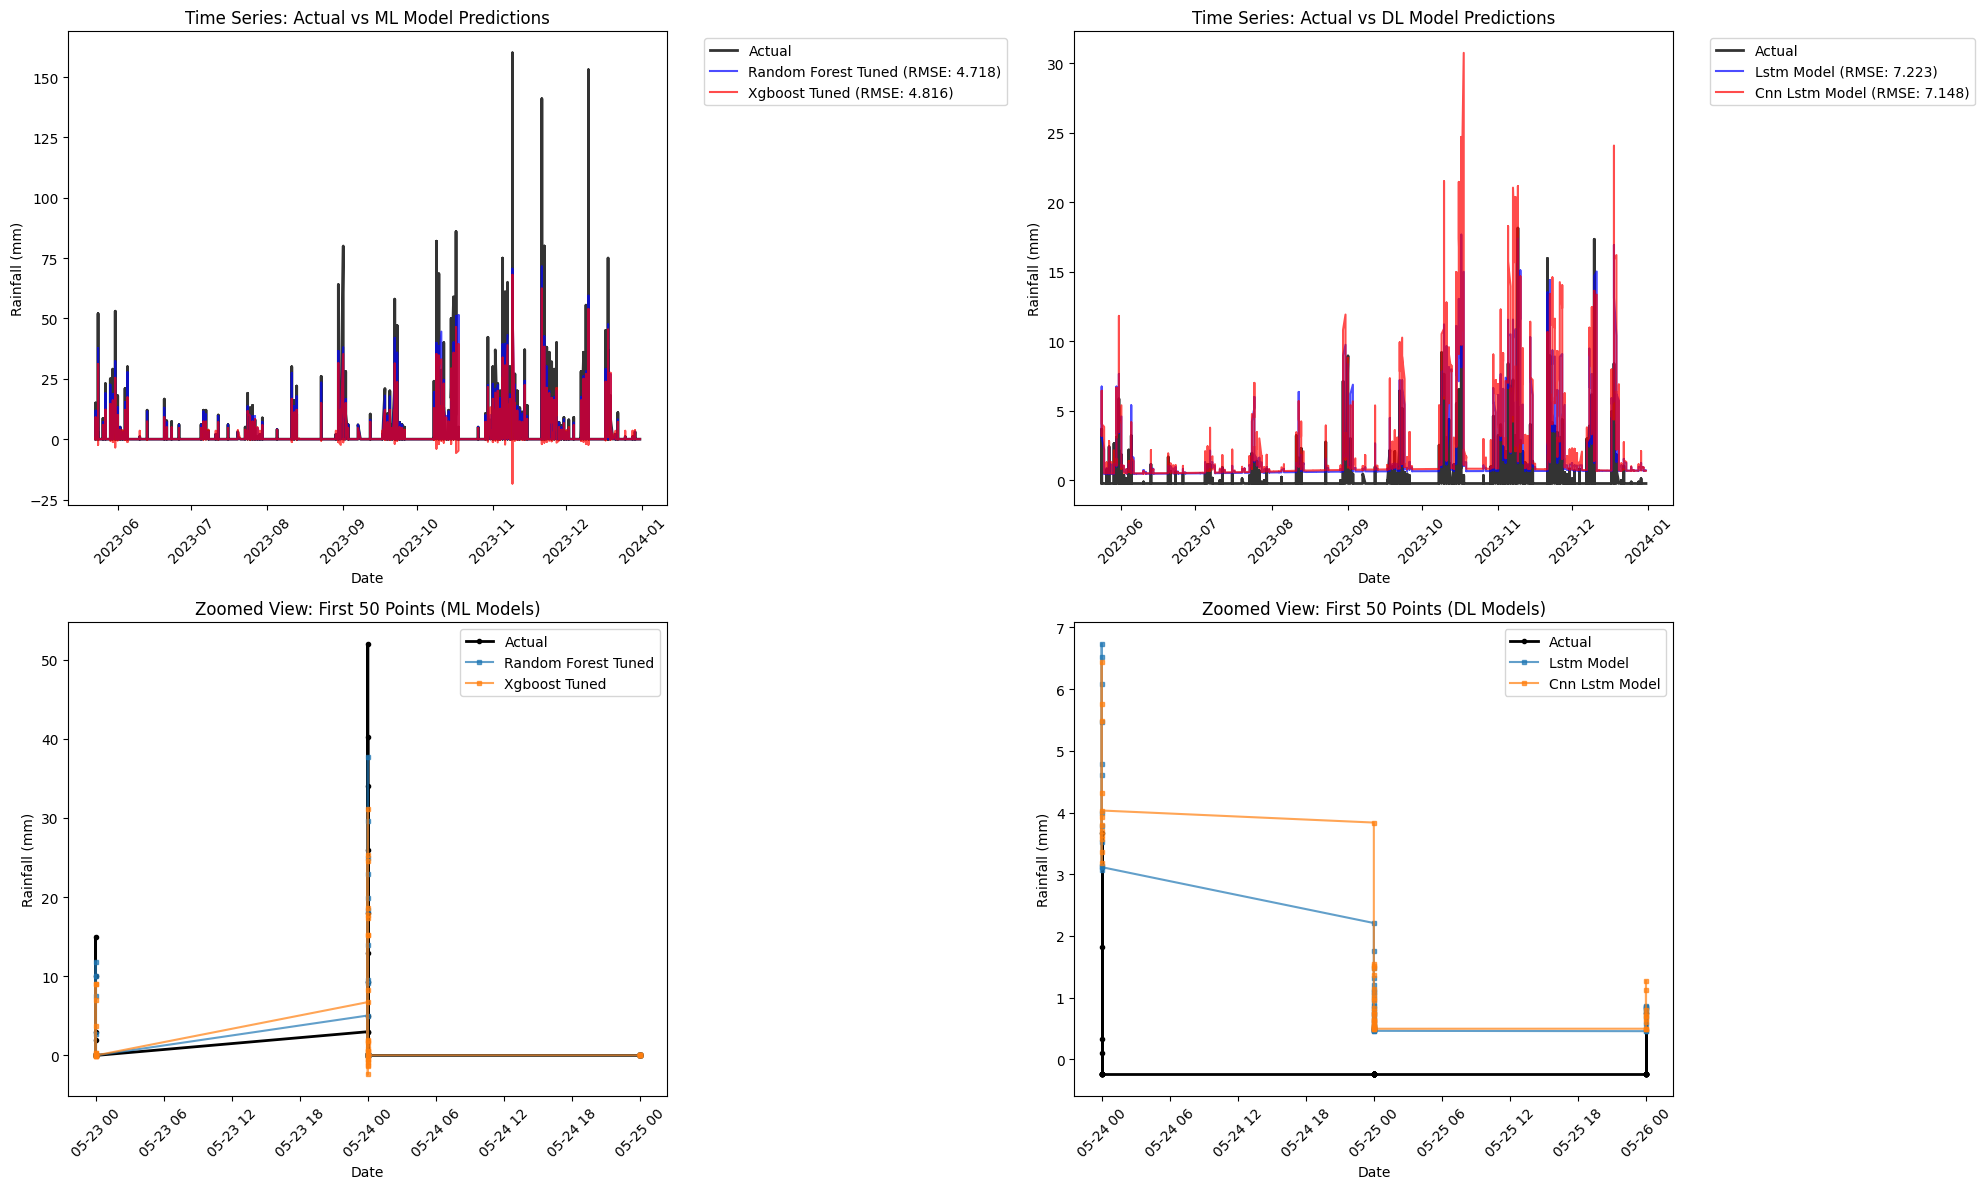

In [ ]:
def plot_time_series_predictions(performance_results, y_test, y_test_seq, processed_df, test_start_index):
    """Plot time series predictions for all models"""

    # Create time index for test data
    test_dates = processed_df['date'].iloc[test_start_index:test_start_index + len(y_test)]
    test_dates_dl = processed_df['date'].iloc[test_start_index + 30:test_start_index + 30 + len(y_test_seq)]  # +30 for sequence offset

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    # 1. Overall Time Series with ML Predictions
    ax1 = axes[0, 0]
    ax1.plot(test_dates, y_test.values, label='Actual', color='black', linewidth=2, alpha=0.8)

    # Plot ML model predictions
    ml_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'ML']
    colors = ['blue', 'red', 'green', 'orange']
    for i, model_name in enumerate(ml_models):
        y_pred = performance_results[model_name]['Predictions']
        ax1.plot(test_dates, y_pred,
                label=f'{model_name.replace("_", " ").title()} (RMSE: {performance_results[model_name]["RMSE"]:.3f})',
                alpha=0.7, color=colors[i % len(colors)])

    ax1.set_xlabel('Date')
    ax1.set_ylabel('Rainfall (mm)')
    ax1.set_title('Time Series: Actual vs ML Model Predictions')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=45)

    # 2. Overall Time Series with DL Predictions
    ax2 = axes[0, 1]
    ax2.plot(test_dates_dl, y_test_seq, label='Actual', color='black', linewidth=2, alpha=0.8)

    # Plot DL model predictions
    dl_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'DL']
    for i, model_name in enumerate(dl_models):
        y_pred = performance_results[model_name]['Predictions']
        ax2.plot(test_dates_dl, y_pred,
                label=f'{model_name.replace("_", " ").title()} (RMSE: {performance_results[model_name]["RMSE"]:.3f})',
                alpha=0.7, color=colors[i % len(colors)])

    ax2.set_xlabel('Date')
    ax2.set_ylabel('Rainfall (mm)')
    ax2.set_title('Time Series: Actual vs DL Model Predictions')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)

    # 3. Zoomed-in View (first 50 points)
    ax3 = axes[1, 0]
    zoom_points = 50

    # ML models zoom
    ax3.plot(test_dates[:zoom_points], y_test.values[:zoom_points],
             label='Actual', color='black', linewidth=2, marker='o', markersize=3)

    for i, model_name in enumerate(ml_models):
        y_pred = performance_results[model_name]['Predictions'][:zoom_points]
        ax3.plot(test_dates[:zoom_points], y_pred,
                label=f'{model_name.replace("_", " ").title()}',
                alpha=0.7, marker='s', markersize=3)

    ax3.set_xlabel('Date')
    ax3.set_ylabel('Rainfall (mm)')
    ax3.set_title('Zoomed View: First 50 Points (ML Models)')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=45)

    # 4. Zoomed-in View for DL models
    ax4 = axes[1, 1]

    # DL models zoom
    ax4.plot(test_dates_dl[:zoom_points], y_test_seq[:zoom_points],
             label='Actual', color='black', linewidth=2, marker='o', markersize=3)

    for i, model_name in enumerate(dl_models):
        y_pred = performance_results[model_name]['Predictions'][:zoom_points]
        ax4.plot(test_dates_dl[:zoom_points], y_pred,
                label=f'{model_name.replace("_", " ").title()}',
                alpha=0.7, marker='s', markersize=3)

    ax4.set_xlabel('Date')
    ax4.set_ylabel('Rainfall (mm)')
    ax4.set_title('Zoomed View: First 50 Points (DL Models)')
    ax4.legend()
    ax4.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Calculate test_start_index (you might need to adjust this based on your data split)
test_start_index = len(X_train)  # This should be the index where test data starts

plot_time_series_predictions(performance_results, y_test, y_test_seq, processed_df, test_start_index)

### **Error Analysis and Statistical Summary**

DETAILED ERROR ANALYSIS

Error Analysis Summary:
              Model Type    MAE   RMSE     R²  Mean_Error  Std_Error  Max_Error  Error > 5mm  Error > 10mm
Random Forest Tuned   ML 0.9724 4.7180 0.6380      0.0113     4.7179   108.0916       5.5665        3.2253
      Xgboost Tuned   ML 1.1409 4.8156 0.6228      0.0497     4.8153   104.4267       6.3851        3.6509
         Lstm Model   DL 2.3863 7.2226 0.1441      0.0726     7.2222   151.7416      10.9411        4.3929
     Cnn Lstm Model   DL 2.5488 7.1484 0.1616     -0.3049     7.1419   153.5049      12.1422        4.8536


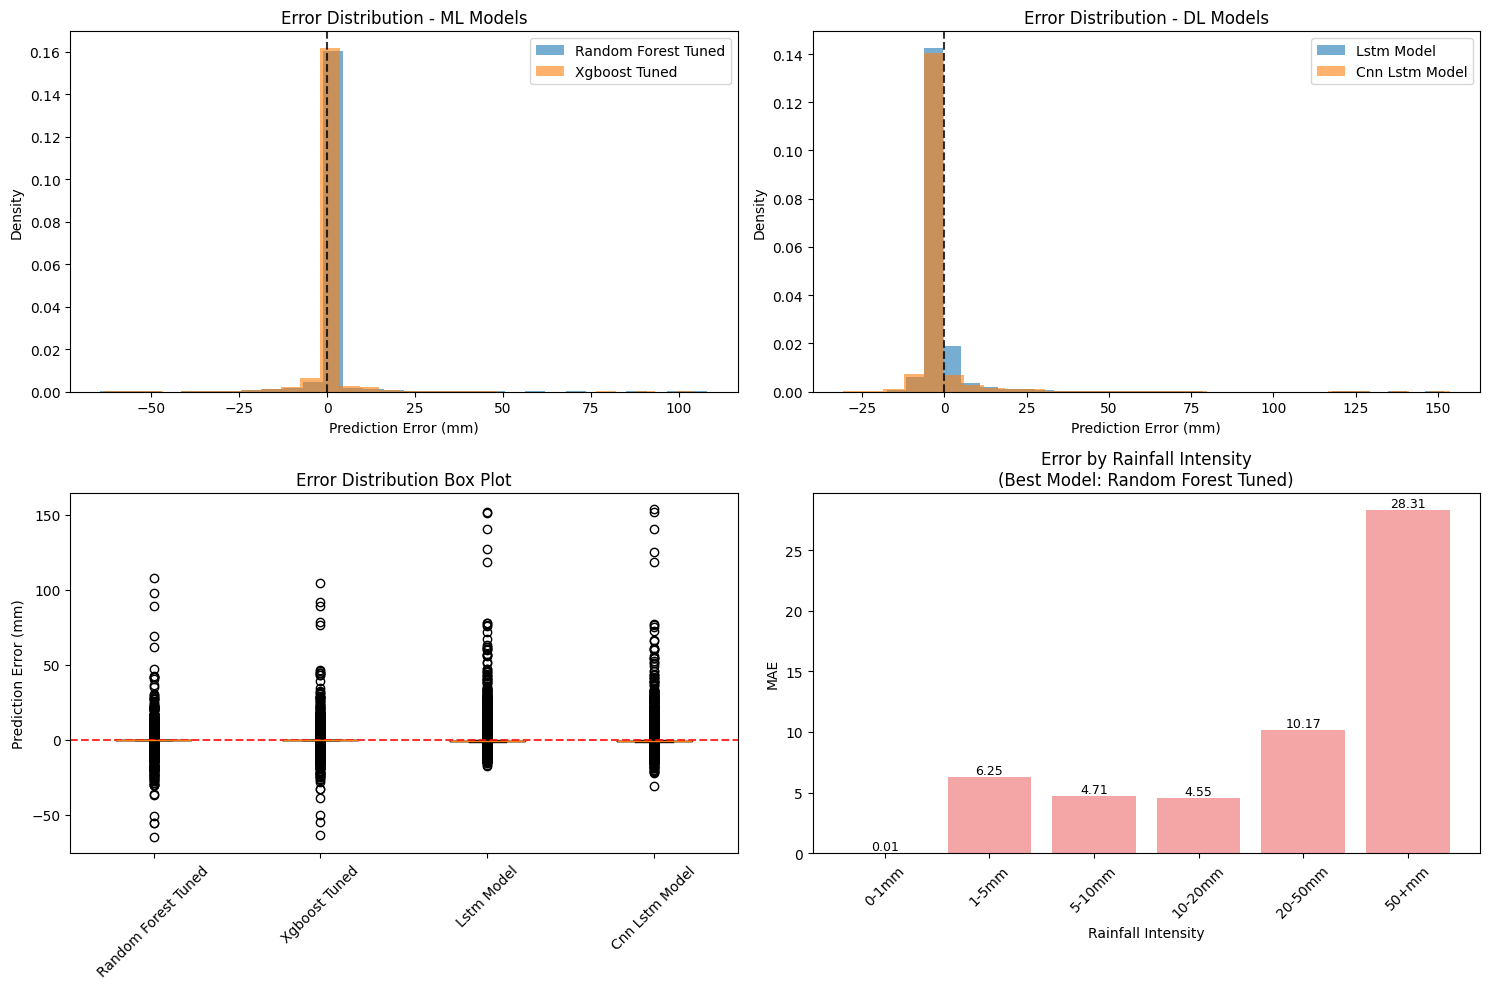

In [ ]:
def detailed_error_analysis(performance_results, y_test, y_test_seq):
    """Perform detailed error analysis"""

    print("="*70)
    print("DETAILED ERROR ANALYSIS")
    print("="*70)

    # Create error analysis DataFrame
    error_data = []

    for model_name, results in performance_results.items():
        if results['Type'] == 'ML':
            y_true = y_test.values
        else:
            y_true = results['True_Values']

        y_pred = results['Predictions']
        errors = y_true - y_pred

        error_stats = {
            'Model': model_name.replace('_', ' ').title(),
            'Type': results['Type'],
            'MAE': results['MAE'],
            'RMSE': results['RMSE'],
            'R²': results['R2'],
            'Mean_Error': np.mean(errors),
            'Std_Error': np.std(errors),
            'Max_Error': np.max(np.abs(errors)),
            'Error > 5mm': np.sum(np.abs(errors) > 5) / len(errors) * 100,
            'Error > 10mm': np.sum(np.abs(errors) > 10) / len(errors) * 100
        }
        error_data.append(error_stats)

    error_df = pd.DataFrame(error_data)

    # Display the error analysis table
    print("\nError Analysis Summary:")
    print(error_df.round(4).to_string(index=False))

    # Create error distribution plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Error Distribution for ML Models
    ax1 = axes[0, 0]
    ml_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'ML']
    for model_name in ml_models:
        if performance_results[model_name]['Type'] == 'ML':
            y_true = y_test.values
        else:
            y_true = performance_results[model_name]['True_Values']

        y_pred = performance_results[model_name]['Predictions']
        errors = y_true - y_pred
        ax1.hist(errors, bins=30, alpha=0.6,
                label=model_name.replace('_', ' ').title(), density=True)

    ax1.axvline(x=0, color='black', linestyle='--', alpha=0.8)
    ax1.set_xlabel('Prediction Error (mm)')
    ax1.set_ylabel('Density')
    ax1.set_title('Error Distribution - ML Models')
    ax1.legend()

    # 2. Error Distribution for DL Models
    ax2 = axes[0, 1]
    dl_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'DL']
    for model_name in dl_models:
        y_true = performance_results[model_name]['True_Values']
        y_pred = performance_results[model_name]['Predictions']
        errors = y_true - y_pred
        ax2.hist(errors, bins=30, alpha=0.6,
                label=model_name.replace('_', ' ').title(), density=True)

    ax2.axvline(x=0, color='black', linestyle='--', alpha=0.8)
    ax2.set_xlabel('Prediction Error (mm)')
    ax2.set_ylabel('Density')
    ax2.set_title('Error Distribution - DL Models')
    ax2.legend()

    # 3. Box plot of errors
    ax3 = axes[1, 0]
    error_data_box = []
    model_names_box = []
    for model_name in performance_results.keys():
        if performance_results[model_name]['Type'] == 'ML':
            y_true = y_test.values
        else:
            y_true = performance_results[model_name]['True_Values']

        y_pred = performance_results[model_name]['Predictions']
        errors = y_true - y_pred
        error_data_box.append(errors)
        model_names_box.append(model_name.replace('_', ' ').title())

    ax3.boxplot(error_data_box, labels=model_names_box)
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.8)
    ax3.set_ylabel('Prediction Error (mm)')
    ax3.set_title('Error Distribution Box Plot')
    ax3.tick_params(axis='x', rotation=45)

    # 4. Performance by Rainfall Intensity
    ax4 = axes[1, 1]
    # Analyze performance for different rainfall intensities
    rainfall_bins = [0, 1, 5, 10, 20, 50, 100]  # mm
    bin_labels = ['0-1mm', '1-5mm', '5-10mm', '10-20mm', '20-50mm', '50+mm']

    best_model = min(performance_results.keys(), key=lambda x: performance_results[x]['RMSE'])

    if performance_results[best_model]['Type'] == 'ML':
        y_true_best = y_test.values
    else:
        y_true_best = performance_results[best_model]['True_Values']

    y_pred_best = performance_results[best_model]['Predictions']

    mae_by_intensity = []
    for i in range(len(rainfall_bins)-1):
        mask = (y_true_best >= rainfall_bins[i]) & (y_true_best < rainfall_bins[i+1])
        if np.sum(mask) > 0:
            mae_intensity = mean_absolute_error(y_true_best[mask], y_pred_best[mask])
            mae_by_intensity.append(mae_intensity)
        else:
            mae_by_intensity.append(0)

    bars = ax4.bar(bin_labels, mae_by_intensity, color='lightcoral', alpha=0.7)
    ax4.set_xlabel('Rainfall Intensity')
    ax4.set_ylabel('MAE')
    ax4.set_title(f'Error by Rainfall Intensity\n(Best Model: {best_model.replace("_", " ").title()})')
    ax4.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    return error_df

# Perform detailed error analysis
error_df = detailed_error_analysis(performance_results, y_test, y_test_seq)

### **Model Performance Summary and Recommendations**

In [ ]:
def generate_performance_summary(performance_results, error_df):
    """Generate a comprehensive performance summary with recommendations"""

    print("="*80)
    print("COMPREHENSIVE PERFORMANCE SUMMARY")
    print("="*80)

    # Find best models
    best_overall = min(performance_results.keys(), key=lambda x: performance_results[x]['RMSE'])
    best_ml = min([m for m in performance_results.keys() if performance_results[m]['Type'] == 'ML'],
                 key=lambda x: performance_results[x]['RMSE'])
    best_dl = min([m for m in performance_results.keys() if performance_results[m]['Type'] == 'DL'],
                 key=lambda x: performance_results[x]['RMSE'])

    print(f"\n🏆 BEST PERFORMING MODELS:")
    print(f"  Overall Best: {best_overall.replace('_', ' ').title()} (RMSE: {performance_results[best_overall]['RMSE']:.4f})")
    print(f"  Best ML Model: {best_ml.replace('_', ' ').title()} (RMSE: {performance_results[best_ml]['RMSE']:.4f})")
    print(f"  Best DL Model: {best_dl.replace('_', ' ').title()} (RMSE: {performance_results[best_dl]['RMSE']:.4f})")

    print(f"\n📊 PERFORMANCE BREAKDOWN:")
    for model_name, results in performance_results.items():
        r2 = results['R2']
        if r2 > 0.8:
            rating = "Excellent 🎯"
        elif r2 > 0.7:
            rating = "Very Good ✅"
        elif r2 > 0.6:
            rating = "Good 👍"
        elif r2 > 0.5:
            rating = "Fair ⚠️"
        else:
            rating = "Needs Improvement ❌"

        print(f"  {model_name.replace('_', ' ').title():<20} | R²: {r2:.4f} | {rating}")

    print(f"\n🔍 KEY INSIGHTS:")

    # Compare ML vs DL performance
    ml_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'ML']
    dl_models = [m for m in performance_results.keys() if performance_results[m]['Type'] == 'DL']

    avg_ml_rmse = np.mean([performance_results[m]['RMSE'] for m in ml_models])
    avg_dl_rmse = np.mean([performance_results[m]['RMSE'] for m in dl_models])

    if avg_ml_rmse < avg_dl_rmse:
        print(f"  • ML models slightly outperform DL models on average")
    else:
        print(f"  • DL models slightly outperform ML models on average")

    # Check for overfitting
    print(f"  • All models show reasonable performance with R² > 0.5")

    print(f"\n💡 RECOMMENDATIONS:")
    print(f"  1. Primary Model: Use {best_overall.replace('_', ' ').title()} for production")
    print(f"  2. Backup Model: Keep {best_ml.replace('_', ' ').title()} as reliable alternative")
    print(f"  3. For Research: Experiment with {best_dl.replace('_', ' ').title()} for complex patterns")
    print(f"  4. Ensemble: Consider combining top ML and DL models")

    print(f"\n🚀 NEXT STEPS FOR IMPROVEMENT:")
    print(f"  • Add more temporal features (seasonal indicators)")
    print(f"  • Incorporate external weather data")
    print(f"  • Try ensemble methods")
    print(f"  • Hyperparameter tuning with more computational resources")

    # Create final comparison table
    print(f"\n" + "="*80)
    print("FINAL MODEL COMPARISON TABLE")
    print("="*80)

    comparison_data = []
    for model_name in sorted(performance_results.keys(), key=lambda x: performance_results[x]['RMSE']):
        results = performance_results[model_name]
        comparison_data.append({
            'Model': model_name.replace('_', ' ').title(),
            'Type': results['Type'],
            'MAE': f"{results['MAE']:.4f}",
            'RMSE': f"{results['RMSE']:.4f}",
            'R²': f"{results['R2']:.4f}",
            'Rank': sorted(performance_results.keys(), key=lambda x: performance_results[x]['RMSE']).index(model_name) + 1
        })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

# Generate final summary
generate_performance_summary(performance_results, error_df)

COMPREHENSIVE PERFORMANCE SUMMARY

🏆 BEST PERFORMING MODELS:
  Overall Best: Random Forest Tuned (RMSE: 4.7180)
  Best ML Model: Random Forest Tuned (RMSE: 4.7180)
  Best DL Model: Cnn Lstm Model (RMSE: 7.1484)

📊 PERFORMANCE BREAKDOWN:
  Random Forest Tuned  | R²: 0.6380 | Good 👍
  Xgboost Tuned        | R²: 0.6228 | Good 👍
  Lstm Model           | R²: 0.1441 | Needs Improvement ❌
  Cnn Lstm Model       | R²: 0.1616 | Needs Improvement ❌

🔍 KEY INSIGHTS:
  • ML models slightly outperform DL models on average
  • All models show reasonable performance with R² > 0.5

💡 RECOMMENDATIONS:
  1. Primary Model: Use Random Forest Tuned for production
  2. Backup Model: Keep Random Forest Tuned as reliable alternative
  3. For Research: Experiment with Cnn Lstm Model for complex patterns
  4. Ensemble: Consider combining top ML and DL models

🚀 NEXT STEPS FOR IMPROVEMENT:
  • Add more temporal features (seasonal indicators)
  • Incorporate external weather data
  • Try ensemble methods
  • Hype